<a href="https://colab.research.google.com/github/henzopuchetti/Analise-IDHM/blob/main/Analise_IDHM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Storytelling com Dados: Explorando o IDHM no Brasil

Neste notebook, vamos explorar o IDHM (Índice de Desenvolvimento Humano Municipal) a partir de uma perspectiva analítica e narrativa.
Nosso objetivo não é apenas descrever números, mas construir uma história com base em evidências, visualizações e interpretações
que ajudem a compreender melhor o desenvolvimento humano no Brasil.

Ao longo da análise, vamos responder principalmente às seguintes perguntas:

- Como o IDHM se distribui entre municípios, estados e regiões do Brasil?
- Quais dimensões (Educação, Renda e Longevidade) mais contribuem para as diferenças de IDHM?
- Existem municípios ou regiões que fogem do padrão esperado?

Vamos seguir o fluxo: **pergunta → exploração → visualização → insight → narrativa final**.



## 2. Importação de bibliotecas e configurações iniciais

In [1]:
#Libs

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("default")
sns.set(style="whitegrid")

#Configuação padrão de tamanho dos Gr´aficos
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

## 3. Contexto e carregamento dos dados

Antes de analisar, precisamos entender **com que dados estamos trabalhando**.
Nesta etapa, vamos carregar a base do IDHM, observar suas principais colunas e conferir o período,
a granularidade (municípios/estados) e os recortes geográficos.

A partir dessa leitura inicial, já começamos a formar uma visão sobre o "universo" que a base representa.


In [2]:
df = pd.read_excel('IDH_2010.xls')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5564 entries, 0 to 5563
Columns: 237 entries, ANO to IDHM Renda
dtypes: float64(159), int64(76), object(2)
memory usage: 10.1+ MB


In [4]:
df.head()

,ANO,Código da Unidade da Federação,Nome da Unidade da Federação,Código do Município,Município,Esperança de vida ao nascer,Taxa de fecundidade total,Mortalidade infantil,Mortalidade até 5 anos de idade,Razão de dependência,...,População de 15 a 17 anos.1,População de 18 anos ou mais.1,População total em domicílios particulares permanentes,"População total em domicílios particulares permanentes, exceto com renda nula",Subíndice de escolaridade - IDHM Educação,Subíndice de frequência escolar - IDHM Educação,IDHM,IDHM Educação,IDHM Longevidade,IDHM Renda
0,2010,11,Rondônia,110001,ALTA FLORESTA D'OESTE,70.75,2.24,23.8,25.49,47.37,...,1602,16431,24097,22429,0.368,0.629,0.641,0.526,0.763,0.657
1,2010,11,Rondônia,110002,ARIQUEMES,73.36,1.91,19.2,20.53,46.68,...,5256,60213,89766,88730,0.514,0.648,0.702,0.600,0.806,0.716
2,2010,11,Rondônia,110003,CABIXI,70.39,2.15,24.8,26.58,48.12,...,381,4306,6303,6156,0.357,0.700,0.650,0.559,0.757,0.650
3,2010,11,Rondônia,110004,CACOAL,74.27,1.90,14.3,15.38,43.79,...,4547,54356,78141,76876,0.488,0.698,0.718,0.620,0.821,0.727
4,2010,11,Rondônia,110005,CEREJEIRAS,72.94,2.12,18.1,19.42,45.67,...,1033,11786,16942,16815,0.430,0.712,0.692,0.602,0.799,0.688


## 4. Entendendo a estrutura do dataset

Agora, vamos entender melhor a estrutura da base:

- Quantas linhas e colunas temos?
- Quais são as principais variáveis numéricas e categóricas?
- Qual o período representado?
- Qual é a unidade de análise (município, estado, ano)?

Essa visão nos ajuda a alinhar a leitura dos dados com as perguntas que queremos responder.


In [5]:
df = df[['Nome da Unidade da Federação', 'Município', 'IDHM', 'IDHM Educação', 'IDHM Longevidade', 'IDHM Renda']]
df.columns = ['uf', 'municipio', 'idhm', 'idhm_educacao', 'idhm_longevidade', 'idhm_renda']
df.head()

,uf,municipio,idhm,idhm_educacao,idhm_longevidade,idhm_renda
0,Rondônia,ALTA FLORESTA D'OESTE,0.641,0.526,0.763,0.657
1,Rondônia,ARIQUEMES,0.702,0.600,0.806,0.716
2,Rondônia,CABIXI,0.650,0.559,0.757,0.650
3,Rondônia,CACOAL,0.718,0.620,0.821,0.727
4,Rondônia,CEREJEIRAS,0.692,0.602,0.799,0.688


In [15]:
df.describe()

,idhm,idhm_educacao,idhm_longevidade,idhm_renda
count,5564.000000,5564.000000,5564.000000,5564.000000
mean,0.659168,0.559102,0.801568,0.642891
std,0.072000,0.093334,0.044684,0.080658
min,0.418000,0.207000,0.672000,0.400000
25%,0.599000,0.490000,0.769000,0.572000
50%,0.665000,0.560000,0.808000,0.654000
75%,0.718000,0.631000,0.836000,0.707000
max,0.862000,0.825000,0.894000,0.891000


## 5. Qualidade dos dados e preparação

Antes de confiar nos resultados, precisamos verificar a qualidade da base:

- Existem valores faltantes em variáveis importantes?
- Há duplicidade de registros?
- Existem valores fora de faixa (por exemplo, IDHM maior que 1 ou menor que 0)?

Nesta seção, vamos fazer uma checagem rápida e aplicar alguns ajustes necessários.
Isso garante que a história que iremos contar seja construída sobre dados consistentes.


In [16]:
df.isnull().sum()

,0
uf,0
municipio,0
idhm,0
idhm_educacao,0
idhm_longevidade,0
idhm_renda,0


In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df = df.drop_duplicates().reset_index(drop=True)

In [19]:
df[['idhm','idhm_educacao',	'idhm_longevidade',	'idhm_renda']].agg(["min", "max"])

,idhm,idhm_educacao,idhm_longevidade,idhm_renda
min,0.418,0.207,0.672,0.400
max,0.862,0.825,0.894,0.891


## 6. Panorama geral do IDHM no Brasil

Começamos nossa narrativa com uma visão ampla: **como o IDHM se distribui no conjunto de municípios da base?**

Nesta parte, vamos:

- Observar a distribuição do IDHM por meio de histogramas;
- Investigar medidas de tendência central e dispersão;
- Identificar se há assimetrias ou concentrações em determinadas faixas.

Essa visão geral nos ajuda a entender o "retrato médio" do desenvolvimento humano antes de descer para recortes regionais.

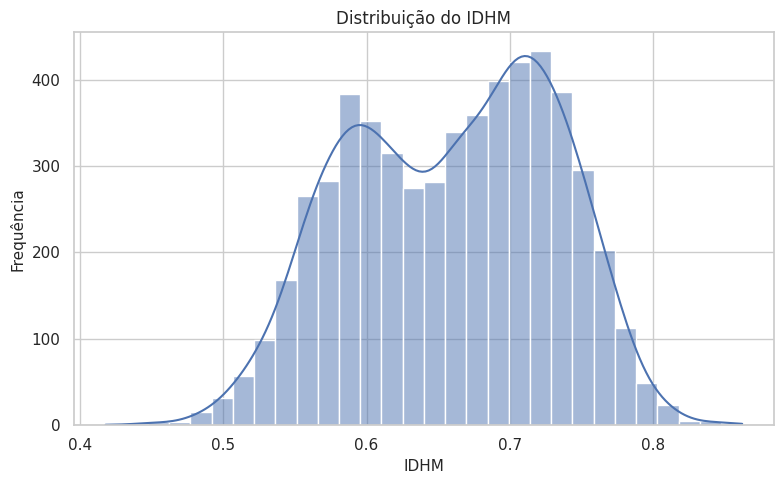

In [20]:
sns.histplot(df["idhm"], bins=30, kde=True)
plt.title("Distribuição do IDHM")
plt.xlabel("IDHM")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

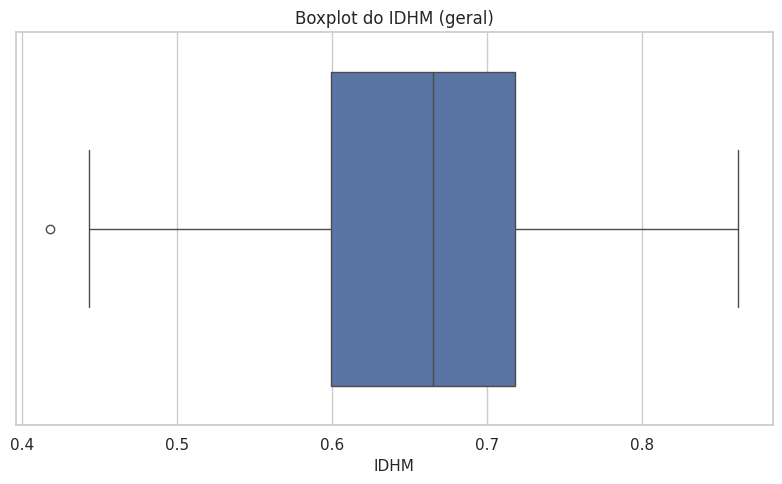

In [21]:
sns.boxplot(x=df["idhm"])
plt.title("Boxplot do IDHM (geral)")
plt.xlabel("IDHM")
plt.tight_layout()
plt.show()

In [22]:
df["idhm"].agg(["mean", "median", "min", "max"])

,idhm
mean,0.659168
median,0.665000
min,0.418000
max,0.862000


## 7. Desigualdades regionais e estaduais

Agora, começamos a responder uma das perguntas centrais:
**como o IDHM varia entre regiões e estados do Brasil?**

Vamos:

- Calcular o IDHM médio e mediano por região e por estado;
- Visualizar essas diferenças com gráficos de barras e boxplots;
- Identificar quais regiões e estados se destacam positiva ou negativamente.

Esses recortes começam a revelar desigualdades territoriais importantes.


In [23]:
# Mapeando nome do estado -> região

mapa_regiao_nome = {
    "Acre": "Norte",
    "Amapá": "Norte",
    "Amazonas": "Norte",
    "Pará": "Norte",
    "Rondônia": "Norte",
    "Roraima": "Norte",
    "Tocantins": "Norte",

    "Alagoas": "Nordeste",
    "Bahia": "Nordeste",
    "Ceará": "Nordeste",
    "Maranhão": "Nordeste",
    "Paraíba": "Nordeste",
    "Pernambuco": "Nordeste",
    "Piauí": "Nordeste",
    "Rio Grande do Norte": "Nordeste",
    "Sergipe": "Nordeste",

    "Distrito Federal": "Centro-Oeste",
    "Goiás": "Centro-Oeste",
    "Mato Grosso": "Centro-Oeste",
    "Mato Grosso do Sul": "Centro-Oeste",

    "Espírito Santo": "Sudeste",
    "Minas Gerais": "Sudeste",
    "Rio de Janeiro": "Sudeste",
    "São Paulo": "Sudeste",

    "Paraná": "Sul",
    "Rio Grande do Sul": "Sul",
    "Santa Catarina": "Sul",
}

df["regiao"] = df["uf"].map(mapa_regiao_nome)

df[["uf", "regiao"]].drop_duplicates().sort_values("regiao")


,uf,regiao
5563,Distrito Federal,Centro-Oeste
5176,Mato Grosso,Centro-Oeste
5098,Mato Grosso do Sul,Centro-Oeste
5317,Goiás,Centro-Oeste
1825,Bahia,Nordeste
1750,Sergipe,Nordeste
1463,Pernambuco,Nordeste
1240,Paraíba,Nordeste
1073,Rio Grande do Norte,Nordeste
1648,Alagoas,Nordeste


In [24]:
# 7.1 IDHM médio por região

idhm_regiao = df.groupby("regiao")["idhm"].mean().sort_values()
idhm_regiao


,idhm
regiao,
Nordeste,0.590672
Norte,0.607951
Centro-Oeste,0.689468
Sudeste,0.698984
Sul,0.714113


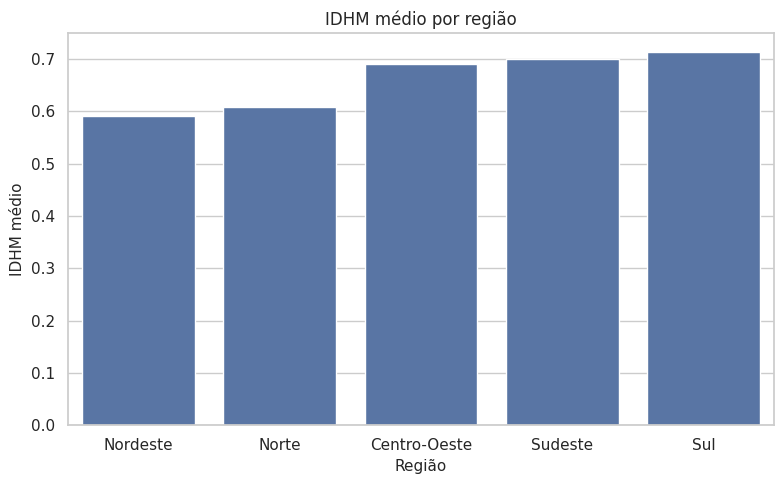

In [25]:
# 7.2 Gráfico de barras – IDHM médio por região

plt.figure()
sns.barplot(x=idhm_regiao.index, y=idhm_regiao.values)
plt.title("IDHM médio por região")
plt.xlabel("Região")
plt.ylabel("IDHM médio")
plt.tight_layout()
plt.show()


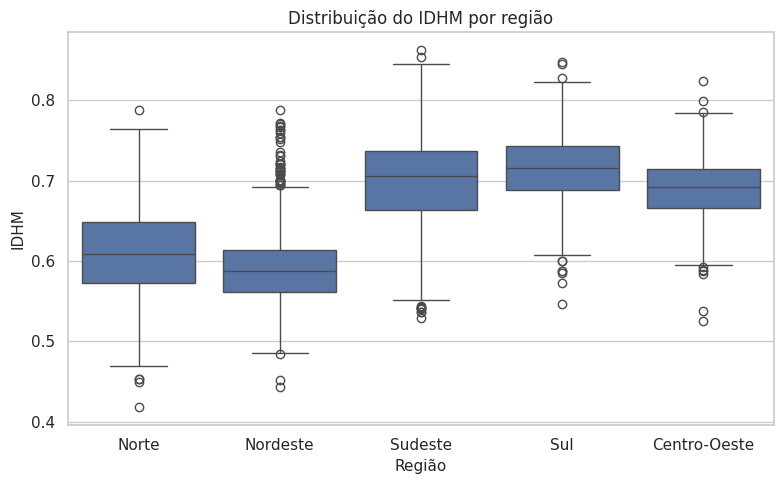

In [26]:
# 7.3 Boxplot do IDHM por região

plt.figure()
sns.boxplot(data=df, x="regiao", y="idhm")
plt.title("Distribuição do IDHM por região")
plt.xlabel("Região")
plt.ylabel("IDHM")
plt.tight_layout()
plt.show()


## 8. O que está por trás do IDHM? (Educação, Renda e Longevidade)

O IDHM é composto por diferentes dimensões.
Nesta seção, vamos analisar separadamente:

- IDHM Educação
- IDHM Renda
- IDHM Longevidade

O objetivo é entender **como cada dimensão se comporta** e **como elas se relacionam entre si e com o IDHM total**.


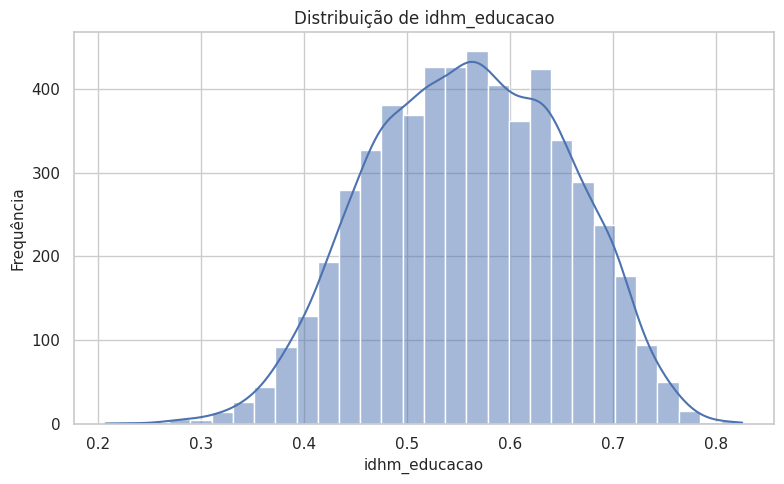

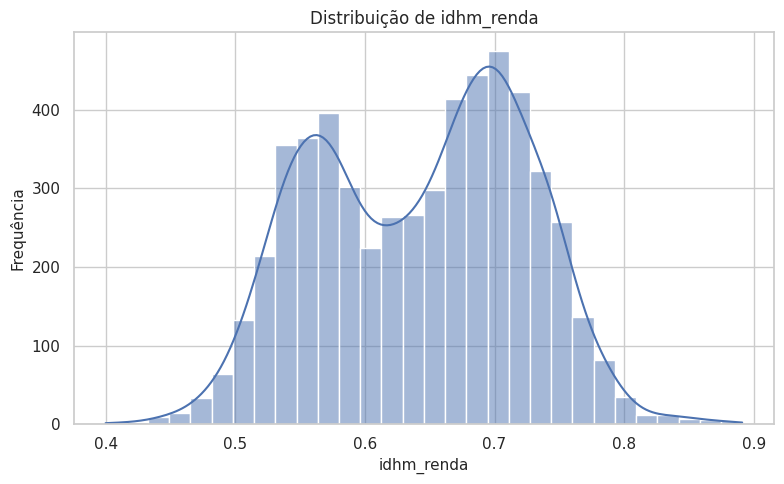

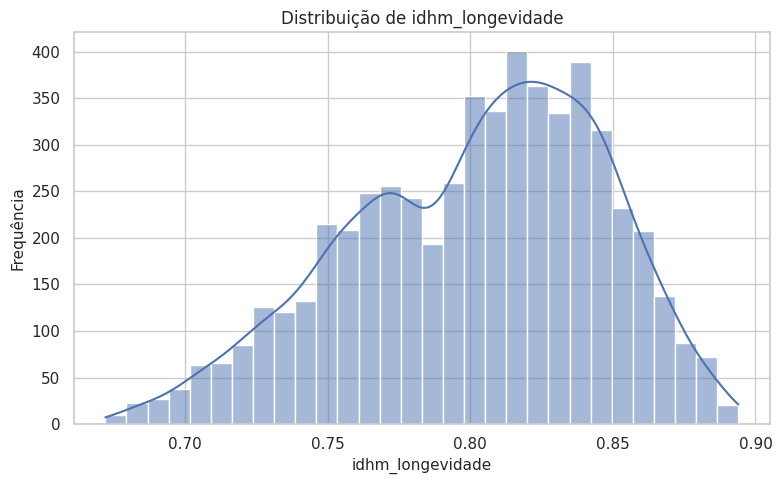

In [27]:
for col in ["idhm_educacao", "idhm_renda", "idhm_longevidade"]:
    if col in df.columns:
        sns.histplot(df[col], bins=30, kde=True)
        plt.title(f"Distribuição de {col}")
        plt.xlabel(col)
        plt.ylabel("Frequência")
        plt.tight_layout()
        plt.show()

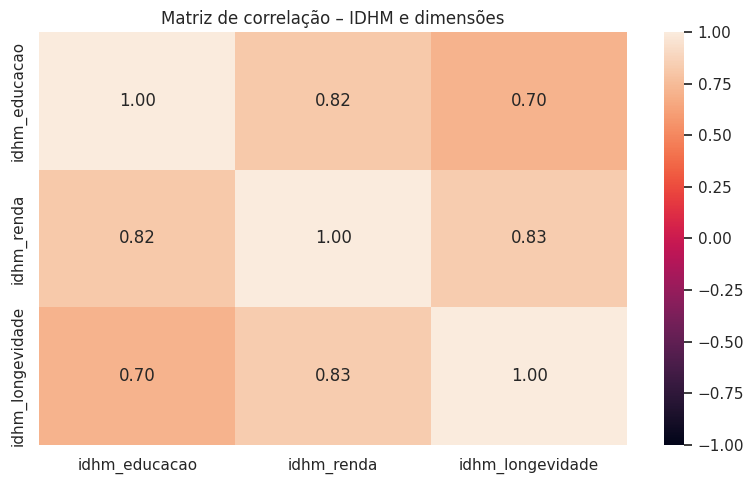

In [28]:
cols_corr = [c for c in ["idhm_educacao", "idhm_renda", "idhm_longevidade"] if c in df.columns]
corr = df[cols_corr].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="rocket", vmin=-1, vmax=1)
plt.title("Matriz de correlação – IDHM e dimensões")
plt.tight_layout()
plt.show()

## 9. Municípios que fogem da curva

Indicadores agregados são importantes, mas histórias interessantes surgem quando
olhamos para municípios que fogem do padrão geral.

Nesta parte, vamos:

- Identificar municípios com IDHM muito alto ou muito baixo;
- Cruzar o IDHM com uma dimensão (por exemplo, Renda) para buscar combinações atípicas;
- Destacar alguns casos que merecem atenção especial.


In [29]:
df.head()

,uf,municipio,idhm,idhm_educacao,idhm_longevidade,idhm_renda,regiao
0,Rondônia,ALTA FLORESTA D'OESTE,0.641,0.526,0.763,0.657,Norte
1,Rondônia,ARIQUEMES,0.702,0.600,0.806,0.716,Norte
2,Rondônia,CABIXI,0.650,0.559,0.757,0.650,Norte
3,Rondônia,CACOAL,0.718,0.620,0.821,0.727,Norte
4,Rondônia,CEREJEIRAS,0.692,0.602,0.799,0.688,Norte


In [30]:
N = 10

if "municipio" in df.columns:
    maiores = df.sort_values("idhm", ascending=False).head(N)[["municipio", "uf", "idhm","regiao"]].copy()
    menores = df.sort_values("idhm", ascending=True).head(N)[["municipio", "uf", "idhm","regiao"]].copy()
else:
    maiores = df.sort_values("idhm", ascending=False).head(N)[["uf", "idhm"]].copy()
    menores = df.sort_values("idhm", ascending=True).head(N)[["uf", "idhm"]].copy()

# Criar coluna indicando se é Top ou Bottom
maiores["tipo"] = "Maiores"
menores["tipo"] = "Menores"

# Unir tudo em um único DataFrame
ranking_idhm = pd.concat([maiores, menores], axis=0).reset_index(drop=True)

ranking_idhm

,municipio,uf,idhm,regiao,tipo
0,SÃO CAETANO DO SUL,São Paulo,0.862,Sudeste,Maiores
1,ÁGUAS DE SÃO PEDRO,São Paulo,0.854,Sudeste,Maiores
2,FLORIANÓPOLIS,Santa Catarina,0.847,Sul,Maiores
3,VITÓRIA,Espírito Santo,0.845,Sudeste,Maiores
4,BALNEÁRIO CAMBORIÚ,Santa Catarina,0.845,Sul,Maiores
5,SANTOS,São Paulo,0.840,Sudeste,Maiores
6,NITERÓI,Rio de Janeiro,0.837,Sudeste,Maiores
7,JOAÇABA,Santa Catarina,0.827,Sul,Maiores
8,BRASÍLIA,Distrito Federal,0.824,Centro-Oeste,Maiores
9,CURITIBA,Paraná,0.823,Sul,Maiores


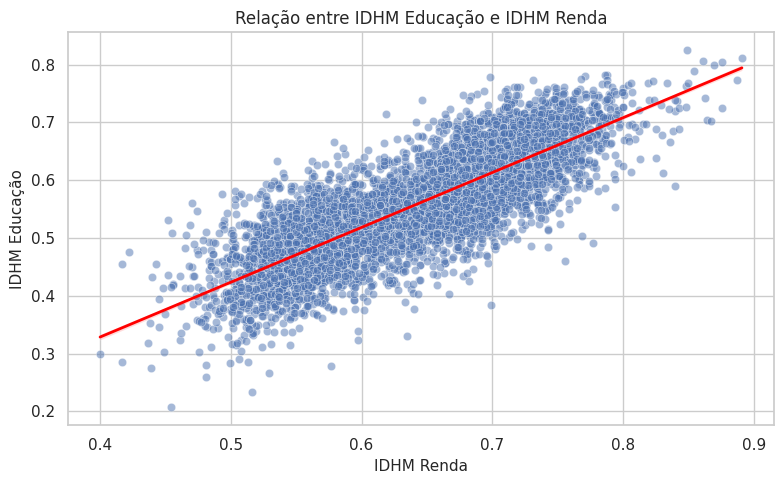

In [31]:
# 9.2 Exemplo de scatter plot – IDHM x IDHM Renda

sns.scatterplot(data=df, x="idhm_renda", y="idhm_educacao", alpha=0.5)

# Linha de tendência com regplot
sns.regplot(
         data=df,
        x="idhm_renda",
        y="idhm_educacao",
        scatter=False,            # não recria os pontos
        color="red",              # linha de tendência em vermelho
        line_kws={"linewidth": 2} # deixa a linha mais grossa
    )

plt.title("Relação entre IDHM Educação e IDHM Renda")
plt.xlabel("IDHM Renda")
plt.ylabel("IDHM Educação")
plt.tight_layout()
plt.show()


## 10. Painel de insights – conectando os pontos

Até aqui, vimos:

- Como o IDHM se distribui no Brasil;
- Quais regiões e estados se destacam positiva ou negativamente;
- Como as dimensões de Educação, Renda e Longevidade se comportam e se relacionam;
- Quais municípios fogem do padrão geral.

Nesta seção, o foco é **síntese**. Em vez de novos gráficos, vamos conectar os achados em uma narrativa:

- Quais padrões chamaram mais atenção?
- Que desigualdades ficaram evidentes?
- Que relações entre dimensões parecem mais fortes?
- Que casos especiais podem motivar análises futuras?

Use este espaço para escrever, em texto, os principais insights que você levaria para um relatório ou apresentação.


## 11. Conclusões e próximos passos

Neste notebook, usamos o IDHM como base para exercitar o **storytelling com dados**:

- Partimos de perguntas claras sobre desigualdade e desenvolvimento humano;
- Exploramos a estrutura e a qualidade da base;
- Construímos visualizações que revelaram padrões, contrastes e relações;
- Identificamos municípios e regiões que fogem do comportamento médio;
- Organizamos os achados em uma narrativa coerente.

Como próximos passos, você pode:

- Aprofundar a análise temporal (comparando anos ou períodos específicos);
- Cruzar o IDHM com outras bases (saúde, educação, renda, infraestrutura);
- Desenvolver modelos preditivos para estimar IDHM em diferentes cenários;
- Criar dashboards interativos que contem essa história para diferentes públicos.

A ideia é que este notebook seja não apenas um exercício técnico,
mas um ponto de partida para novas perguntas e novas histórias sobre o Brasil.
